In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import copy

In [2]:

def veri_yukle(dosya):
    data = np.loadtxt(dosya, delimiter=",")
    x_train = data[:, 0]
    y_train = data[:, 1]
    return x_train, y_train


x_train, y_train = veri_yukle("/content/drive/MyDrive/Colab Notebooks/ex1data1.txt")

print(x_train[:5])
print(y_train[:5])

FileNotFoundError: /content/drive/MyDrive/Colab Notebooks/ex1data1.txt not found.

In [ ]:
print ('X degiskeni sayisi :', x_train.shape)
print ('X degiskeni tipi :', type(x_train))
print ('Ydegiskeni sayisi: ', y_train.shape)
print ('Y degiskeni tipi :', type(y_train))
print ('Ogrenme ornegi sayısı (m):', len(x_train))

X degiskeni sayisi : (97,)
X degiskeni tipi : <class 'numpy.ndarray'>
Ydegiskeni sayisi:  (97,)
Y degiskeni tipi : <class 'numpy.ndarray'>
Ogrenme ornegi sayısı (m): 97


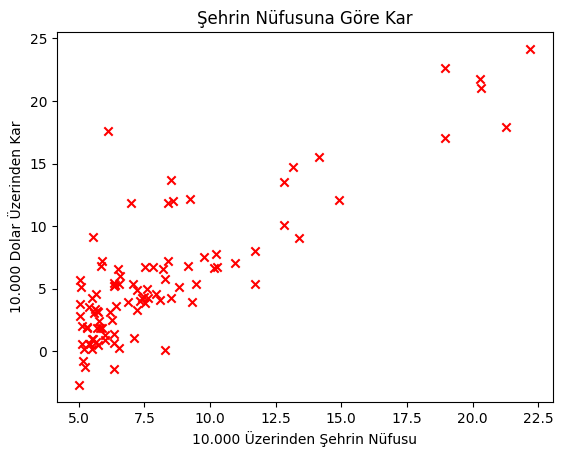

In [ ]:
def verigorsellestir(x,y):
    plt.scatter(x, y, marker='x', c='r')

    plt.title("Şehrin Nüfusuna Göre Kar")

    plt.ylabel('10.000 Dolar Üzerinden Kar')

    plt.xlabel('10.000 Üzerinden Şehrin Nüfusu')
    plt.show()

verigorsellestir(x_train, y_train)

In [ ]:

def h_theta(x, theta_0, theta_1):
    return theta_0 + theta_1 * x

def gradient_hesapla(x, y, theta_0, theta_1):
    m = x.shape[0]
    dJ_dtheta0 = 0
    dJ_dtheta1 = 0
    for i in range(m):
        tahmin = h_theta(x[i], theta_0, theta_1)
        hata = tahmin - y[i]
        dJ_dtheta0 += hata
        dJ_dtheta1 += hata * x[i]
    dJ_dtheta0 /= m
    dJ_dtheta1 /= m
    return dJ_dtheta0, dJ_dtheta1

In [ ]:

def maliyet_hesapla(x, y, theta_0, theta_1):
    m = x.shape[0]
    toplam_maliyet = 0
    for i in range(m):
        tahmin = h_theta(x[i], theta_0, theta_1)
        toplam_maliyet += (tahmin - y[i]) ** 2
    return toplam_maliyet / (2 * m)

def gradient_descent(x, y, theta_0_init, theta_1_init, alpha, iterations):
    theta_0 = theta_0_init
    theta_1 = theta_1_init
    J_history = []
    theta_0_history = []
    theta_1_history = []
    for i in range(iterations):
        dJ_dtheta0, dJ_dtheta1 = gradient_hesapla(x, y, theta_0, theta_1)
        theta_0 -= alpha * dJ_dtheta0
        theta_1 -= alpha * dJ_dtheta1

        J = maliyet_hesapla(x, y, theta_0, theta_1)
        J_history.append(J)
        theta_0_history.append(theta_0)
        theta_1_history.append(theta_1)


    return np.array([theta_0, theta_1]), J_history, theta_0_history, theta_1_history

In [ ]:

theta_init = np.array([0.0, 0.0])
alpha = 0.01
iterations = 1500

theta_learned, J_history, theta_0_history, theta_1_history = gradient_descent(
    x_train, y_train,
    theta_init[0], theta_init[1],
    alpha, iterations
)

print("Öğrenilen theta değerleri:", theta_learned)


Öğrenilen theta değerleri: [-3.63029144  1.16636235]


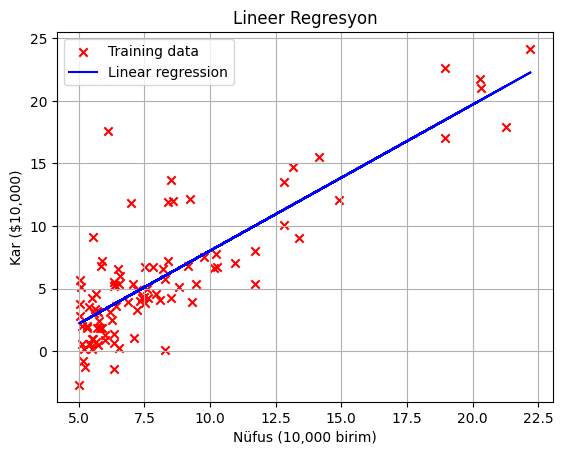

In [ ]:

def plot_fit(x, y, theta_0, theta_1):
    plt.scatter(x, y, marker='x', c='r', label='Training data')
    y_pred = theta_0 + theta_1 * x
    plt.plot(x, y_pred, label='Linear regression', color='blue')
    plt.xlabel('Nüfus (10,000 birim)')
    plt.ylabel('Kar ($10,000)')
    plt.legend()
    plt.grid(True)
    plt.title("Lineer Regresyon")
    plt.show()

plot_fit(x_train, y_train, theta_learned[0], theta_learned[1])


In [ ]:
print(f"100,000 nüfus için tahmin edilen kar: ${h_theta(10.0,theta_learned[0], theta_learned[1]) * 10000:.2f}")

100,000 nüfus için tahmin edilen kar: $80333.32


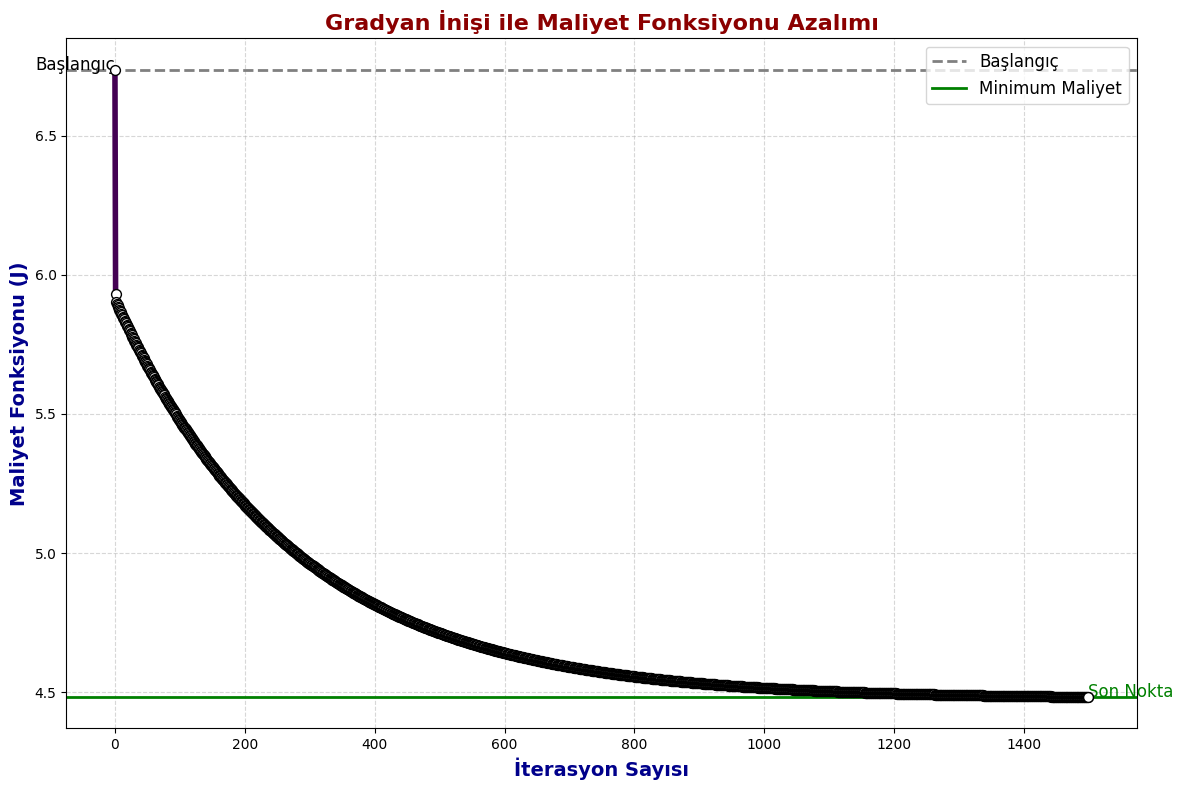

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cost(J_history):
    plt.figure(figsize=(12, 8))

    colors = plt.cm.viridis(np.linspace(0, 1, len(J_history)))
    for i in range(1, len(J_history)):
        plt.plot([i-1, i], [J_history[i-1], J_history[i]], color=colors[i], lw=4)

    plt.scatter(range(len(J_history)), J_history, color='white', edgecolors='black', s=50, zorder=5)

    plt.xlabel("İterasyon Sayısı", fontsize=14, fontweight='bold', color='darkblue')
    plt.ylabel("Maliyet Fonksiyonu (J)", fontsize=14, fontweight='bold', color='darkblue')
    plt.title("Gradyan İnişi ile Maliyet Fonksiyonu Azalımı", fontsize=16, fontweight='bold', color='darkred')

    plt.grid(True, linestyle='--', alpha=0.5)

    plt.axhline(y=J_history[0], color='gray', linestyle='--', linewidth=2, label='Başlangıç')
    plt.axhline(y=min(J_history), color='green', linestyle='-', linewidth=2, label='Minimum Maliyet')

    plt.text(0, J_history[0], 'Başlangıç', fontsize=12, color='black', ha='right')
    plt.text(len(J_history)-1, min(J_history), 'Son Nokta', fontsize=12, color='green', ha='left')

    plt.legend(loc='upper right', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_cost(J_history)


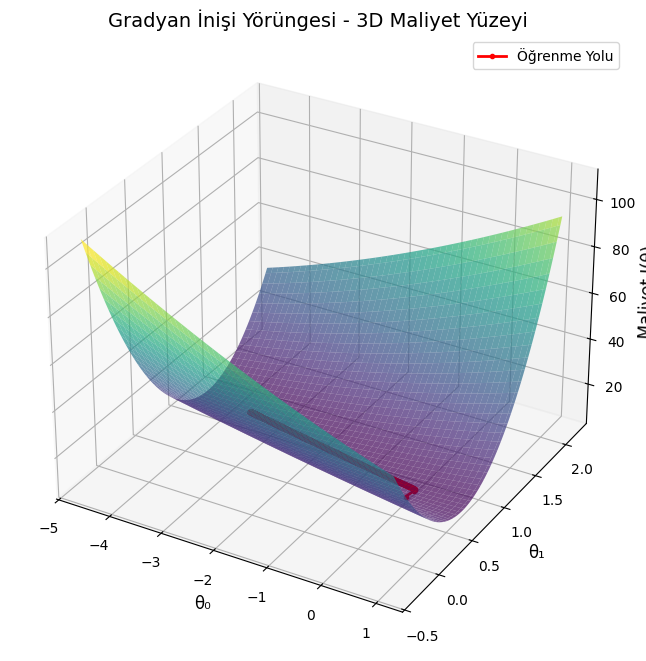

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

theta0_vals = np.linspace(min(theta_0_history) - 1, max(theta_0_history) + 1, 100)
theta1_vals = np.linspace(min(theta_1_history) - 1, max(theta_1_history) + 1, 100)
theta0_grid, theta1_grid = np.meshgrid(theta0_vals, theta1_vals)

J_vals = np.zeros(theta0_grid.shape)
for i in range(theta0_grid.shape[0]):
    for j in range(theta0_grid.shape[1]):
        J_vals[i, j] = maliyet_hesapla(x_train, y_train, theta0_grid[i, j], theta1_grid[i, j])

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(theta0_grid, theta1_grid, J_vals, cmap=cm.viridis, alpha=0.7)

ax.plot(theta_0_history, theta_1_history, J_history, color='red', marker='o', markersize=3, linewidth=2, label='Öğrenme Yolu')

ax.set_xlabel("θ₀", fontsize=12)
ax.set_ylabel("θ₁", fontsize=12)
ax.set_zlabel("Maliyet J(θ)", fontsize=12)
ax.set_title("Gradyan İnişi Yörüngesi - 3D Maliyet Yüzeyi", fontsize=14)
ax.legend()

plt.show()



/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


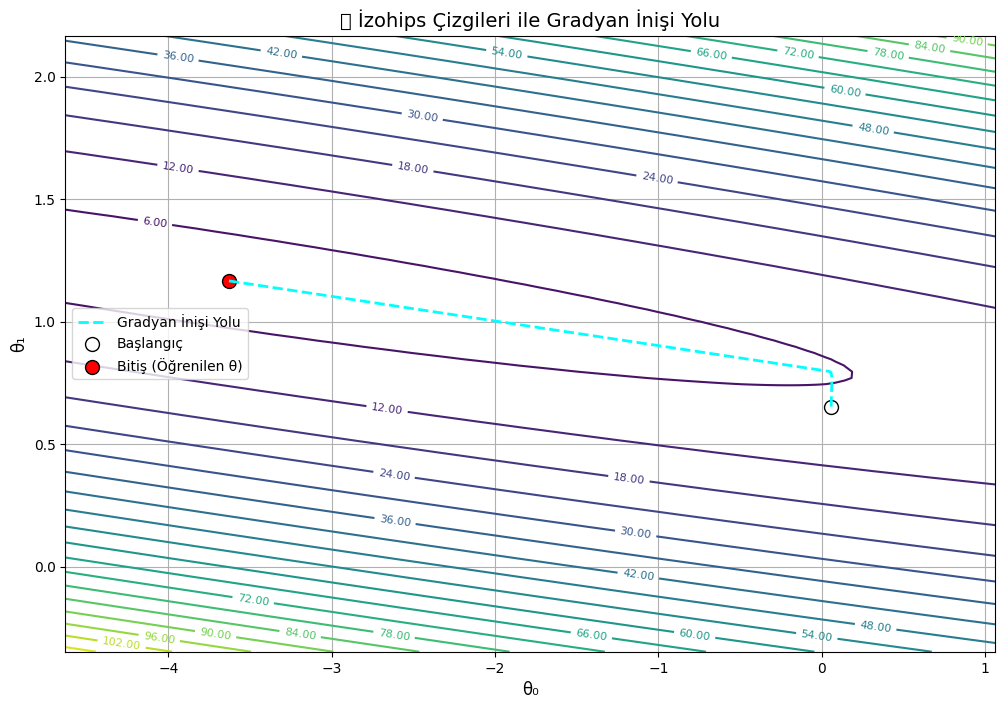

In [ ]:
plt.figure(figsize=(12, 8))

contours = plt.contour(theta0_grid, theta1_grid, J_vals, levels=20, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8, fmt="%.2f")

plt.plot(theta_0_history, theta_1_history, color='cyan', linestyle='--', linewidth=2, label='Gradyan İnişi Yolu')

plt.scatter(theta_0_history[0], theta_1_history[0], color='white', edgecolor='black', s=100, label='Başlangıç')
plt.scatter(theta_0_history[-1], theta_1_history[-1], color='red', edgecolor='black', s=100, label='Bitiş (Öğrenilen θ)')

plt.xlabel("θ₀", fontsize=12)
plt.ylabel("θ₁", fontsize=12)
plt.title("🔍 İzohips Çizgileri ile Gradyan İnişi Yolu", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()
